In [6]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, Dataset


SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

sns.set_theme(style="whitegrid", context="notebook")
DEVICE = torch.device("cpu")
print("PyTorch", torch.__version__, "| устройство:", DEVICE)

PyTorch 2.14.0+cpu | устройство: cpu


In [7]:
from pathlib import Path
train = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\train.csv")
validation = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\validation.csv")
test = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\test.csv")

feature_columns = [
    column
    for column in train.columns
    if column not in {"row_id", "target"}
]

validation_features = [
    column
    for column in validation.columns
    if column not in {"row_id", "target"}
]

test_features = [
    column
    for column in test.columns
    if column != "row_id"
]

assert feature_columns == validation_features == test_features

X_train = train[feature_columns]
y_train = train["target"]

X_validation = validation[feature_columns]
y_validation = validation["target"]

X_test = test[feature_columns]

In [8]:
test.head()

,row_id,f0000,f0001,f0002,f0003,f0004,f0005,f0006,f0007,f0008,...,f0502,f0503,f0504,f0505,f0506,f0507,f0508,f0509,f0510,f0511
0,row_46ad1afad8562239f79c,0.244810,0.114570,0.007334,0.023760,0.387686,0.149363,0.945092,0.013998,0.000000,...,0.275527,0.248542,0.292501,0.260105,0.075953,0.119261,0.098756,0.215996,0.578230,0.000233
1,row_b42ade9cd57b8d919acb,1.896484,0.131558,0.095100,0.102150,0.008930,0.092205,0.130427,0.019269,0.700132,...,0.078451,0.094636,0.127212,0.052143,0.707156,0.747834,0.129984,0.242671,0.692840,0.194765
2,row_c951cd5e197b6b4e8b83,1.521355,0.284507,0.409720,0.207996,0.011174,1.192619,0.790904,0.139842,0.120414,...,0.273042,0.075460,0.864784,0.563859,0.148395,0.194541,0.161783,0.412439,1.115551,0.059842
3,row_a54b3423760d599416ce,2.427760,0.875640,1.255399,0.113083,0.182349,1.190072,1.121677,0.397405,0.631804,...,2.586512,1.683931,1.133419,1.548128,0.126427,7.058036,0.229949,0.278353,3.893234,0.067383
4,row_a87c87cc47690e2a303f,1.392432,0.120985,0.118925,0.568936,0.293686,0.628145,0.508286,0.019553,0.445561,...,0.413616,0.258653,0.265331,0.161138,0.068309,1.087377,0.058649,0.169336,0.004852,0.056881


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

TreeModel = DecisionTreeClassifier(random_state=42)
param_grid = {
    'criterion': ['gini'],
    'max_depth': [8, 9, 10, 11, 12],
    'max_features': [0.4, 0.5, 0.6],
    'min_samples_leaf': [16, 20, 24, 28],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    estimator=TreeModel,
    param_grid=param_grid,
    cv = 5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train,y_train)
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший результат (roc_auc):", grid_search.best_score_)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 20, 'min_samples_split': 2}
Лучший результат (roc_auc): 0.7712002393550013


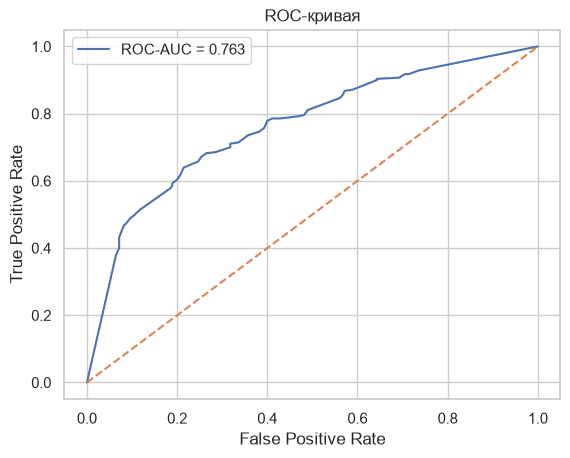

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
BestTreeModel = DecisionTreeClassifier(criterion='gini',max_depth=10,min_samples_leaf=20,min_samples_split=2,max_features=0.5)
#параметры были найдены через GridSearchCV
BestTreeModel.fit(X_train,y_train)
probabilities = BestTreeModel.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

После поиска гиперпараметров через GridSearchCV и сужения поиска вокруг точек, получили значения ROC-AUC = 0.783. Для дерева можно считать это максимумом

In [11]:
from sklearn.ensemble import RandomForestClassifier

RandForest = RandomForestClassifier(n_estimators=1000,min_samples_split = 2,min_samples_leaf=1,criterion='gini',max_features='sqrt',max_depth=None,random_state=42)
param_grid = {
    'max_features': [0.1, 0.15, 0.2, 0.25, 0.3]
}
grid_search = GridSearchCV(
    estimator=RandForest,
    param_grid=param_grid,
    cv = 5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train,y_train)
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший результат (roc_auc):", grid_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Лучшие параметры: {'max_features': 0.15}
Лучший результат (roc_auc): 0.8988882590073066


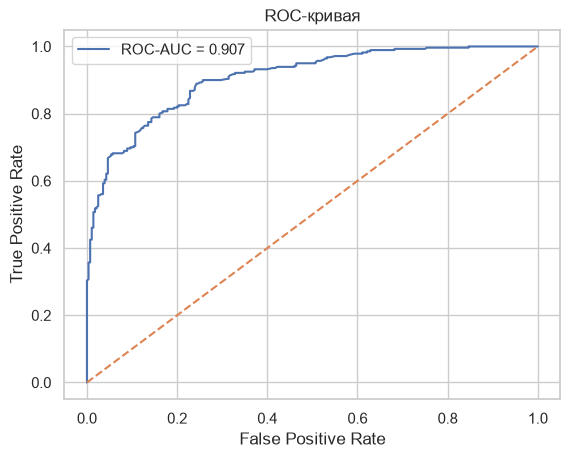

In [21]:
BestRandForest = RandomForestClassifier(n_estimators=1000,criterion='gini',max_depth=None,min_samples_leaf=1,min_samples_split=2,max_features=0.15)
#параметры были найдены через GridSearchCV
BestRandForest.fit(X_train,y_train)
probabilities = BestRandForest.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

Как видим значений ROC-AuC значительное увеличились и составили 0.924, поэтому можно перейти к градиент бустингу

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gBC = GradientBoostingClassifier(criterion='friedman_mse',max_features='sqrt',n_estimators=600,max_depth=5,learning_rate=0.15, random_state=42,min_samples_leaf=2,min_samples_split=2)
param_grid = {
    'criterion': ['friedman_mse', 'squared_error']
}
grid_search = GridSearchCV(
    estimator=gBC,
    param_grid=param_grid,
    cv = 5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train,y_train)
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший результат (roc_auc):", grid_search.best_score_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits


c:\Users\Booss\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\ensemble\_gb.py:666: FutureWarning: The parameter `criterion` is deprecated and will be removed in 1.11. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


Лучшие параметры: {'criterion': 'friedman_mse'}
Лучший результат (roc_auc): 0.9108906525573192


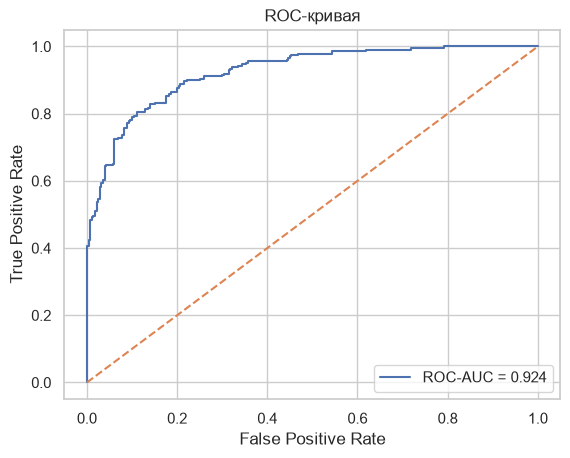

In [22]:
BestGradientBoost = GradientBoostingClassifier(n_estimators=600,max_depth=5,learning_rate=0.15, random_state=42)
#параметры были найдены через GridSearchCV
BestGradientBoost.fit(X_train,y_train)
probabilities = BestGradientBoost.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, probabilities)
auc = roc_auc_score(y_validation, probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [ ]:
p_rf = BestRandForest.predict_proba(X_validation)[:, 1]
p_gb = BestGradientBoost.predict_proba(X_validation)[:, 1]

for w in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    p = w * p_rf + (1 - w) * p_gb
    print(w, roc_auc_score(y_validation, p))

0.2 0.9189285714285713
0.3 0.9191836734693878
0.4 0.9191454081632654
0.5 0.9188520408163265
0.6 0.9180484693877551
0.7 0.917359693877551
0.8 0.9162372448979592


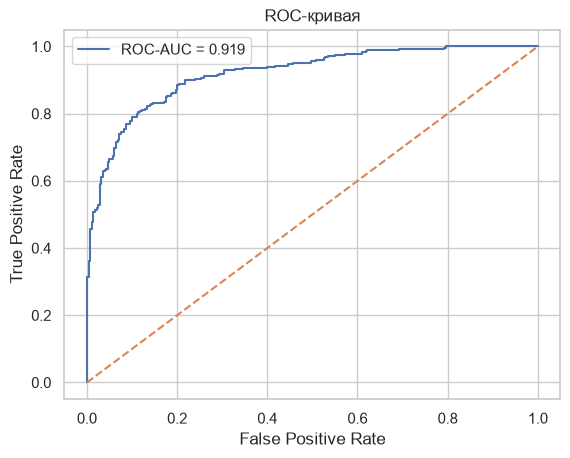

In [24]:
probabilities = BestGradientBoost.predict_proba(X_validation)[:,1]
w = 0.3
fpr, tpr, thresholds = roc_curve(y_validation, w * p_rf + (1 - w) * p_gb)
auc = roc_auc_score(y_validation, w * p_rf + (1 - w) * p_gb)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [16]:
print(X_train.columns)
print(X_validation.columns)
print(X_test.columns)
print(X_test.shape)

Index(['f0000', 'f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'f0006', 'f0007',
       'f0008', 'f0009',
       ...
       'f0502', 'f0503', 'f0504', 'f0505', 'f0506', 'f0507', 'f0508', 'f0509',
       'f0510', 'f0511'],
      dtype='str', length=512)
Index(['f0000', 'f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'f0006', 'f0007',
       'f0008', 'f0009',
       ...
       'f0502', 'f0503', 'f0504', 'f0505', 'f0506', 'f0507', 'f0508', 'f0509',
       'f0510', 'f0511'],
      dtype='str', length=512)
Index(['f0000', 'f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'f0006', 'f0007',
       'f0008', 'f0009',
       ...
       'f0502', 'f0503', 'f0504', 'f0505', 'f0506', 'f0507', 'f0508', 'f0509',
       'f0510', 'f0511'],
      dtype='str', length=512)
(1116, 512)


In [17]:
sample_submission = pd.read_csv(r"C:\Users\Booss\Documents\projects\works\csv-ки\sample_submission.csv")

print(sample_submission.columns)
print(sample_submission.head())
print(sample_submission.shape)

Index(['row_id', 'target'], dtype='str')
                     row_id  target
0  row_46ad1afad8562239f79c     0.5
1  row_b42ade9cd57b8d919acb     0.5
2  row_c951cd5e197b6b4e8b83     0.5
3  row_a54b3423760d599416ce     0.5
4  row_a87c87cc47690e2a303f     0.5
(1116, 2)


In [18]:

gb_final = GradientBoostingClassifier(
    learning_rate=0.15,
    max_depth=5,
    n_estimators=600,
    random_state=42
)

gb_final.fit(X_train, y_train)

test_proba = gb_final.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'row_id': test['row_id'],
    'target': test_proba
})

submission.to_csv('submission.csv', index=False)

In [19]:
print(submission.shape)
print(submission.columns)
print(submission["row_id"].nunique())
print(submission["target"].min())
print(submission["target"].max())

(1116, 2)
Index(['row_id', 'target'], dtype='str')
1116
9.620629359055208e-13
0.9999999999640681


In [25]:
p_tree = BestTreeModel.predict_proba(X_validation)[:, 1]
p_rf = BestRandForest.predict_proba(X_validation)[:, 1]
p_gb = BestGradientBoost.predict_proba(X_validation)[:, 1]

print("Tree:", roc_auc_score(y_validation, p_tree))
print("RF:", roc_auc_score(y_validation, p_rf))
print("GB:", roc_auc_score(y_validation, p_gb))

Tree: 0.7631632653061224
RF: 0.9069387755102041
GB: 0.9242984693877551


In [20]:
print(submission.head(10))
print(submission.tail(10))

                     row_id        target
0  row_46ad1afad8562239f79c  9.999996e-01
1  row_b42ade9cd57b8d919acb  9.999522e-01
2  row_c951cd5e197b6b4e8b83  4.004273e-01
3  row_a54b3423760d599416ce  1.991493e-08
4  row_a87c87cc47690e2a303f  1.000000e+00
5  row_ed4ebd22745eb750fb85  9.999999e-01
6  row_a9274d52b5b258adc867  3.937152e-07
7  row_ce5ec3e8b85ad36bd3dc  9.578029e-10
8  row_6893a3fde5d281930331  3.089151e-09
9  row_edf1956cd38509ad1888  9.710502e-09
                        row_id    target
1106  row_5b7381f51c941d1ab7e5  0.999936
1107  row_4f68f06c656da7a087a3  0.000111
1108  row_104ac9c679e1607018d7  0.997102
1109  row_4bc1c019bb9e5c289889  0.999569
1110  row_142a5a90c49d3f11993a  0.987499
1111  row_bc0491a94a16cffd7ad0  0.999997
1112  row_cd4a11fa653fb6833bb4  1.000000
1113  row_cf61acdf340d40e01df6  0.999717
1114  row_3de5f06f0324e622a5f1  0.010837
1115  row_bad565193cfa2758ba6d  1.000000


In [26]:
from sklearn.ensemble import ExtraTreesClassifier

extra = ExtraTreesClassifier(
    n_estimators=1000,
    max_features=0.2,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

extra.fit(X_train, y_train)

p_extra = extra.predict_proba(X_validation)[:, 1]

print(
    "ExtraTrees:",
    roc_auc_score(y_validation, p_extra)
)

ExtraTrees: 0.9218686224489796


In [27]:
for w_rf in [0, 0.1, 0.2, 0.3]:
    for w_extra in [0, 0.1, 0.2, 0.3]:
        
        w_gb = 1 - w_rf - w_extra
        
        if w_gb < 0:
            continue
        
        p = (
            w_gb * p_gb +
            w_rf * p_rf +
            w_extra * p_extra
        )
        
        score = roc_auc_score(y_validation, p)
        
        print(
            f"GB={w_gb:.1f}, RF={w_rf:.1f}, "
            f"Extra={w_extra:.1f}: {score:.5f}"
        )

GB=1.0, RF=0.0, Extra=0.0: 0.92430
GB=0.9, RF=0.0, Extra=0.1: 0.92589
GB=0.8, RF=0.0, Extra=0.2: 0.92614
GB=0.7, RF=0.0, Extra=0.3: 0.92671
GB=0.9, RF=0.1, Extra=0.0: 0.91971
GB=0.8, RF=0.1, Extra=0.1: 0.92310
GB=0.7, RF=0.1, Extra=0.2: 0.92460
GB=0.6, RF=0.1, Extra=0.3: 0.92559
GB=0.8, RF=0.2, Extra=0.0: 0.91892
GB=0.7, RF=0.2, Extra=0.1: 0.92205
GB=0.6, RF=0.2, Extra=0.2: 0.92335
GB=0.5, RF=0.2, Extra=0.3: 0.92420
GB=0.7, RF=0.3, Extra=0.0: 0.91894
GB=0.6, RF=0.3, Extra=0.1: 0.92117
GB=0.5, RF=0.3, Extra=0.2: 0.92240
GB=0.4, RF=0.3, Extra=0.3: 0.92264


In [30]:
for w in [0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    p = w * p_gb + (1 - w) * p_extra
    
    score = roc_auc_score(y_validation, p)
    
    print(
        f"GB={w:.2f}, "
        f"Extra={1-w:.2f}: "
        f"{score:.6f}"
    )

GB=0.55, Extra=0.45: 0.927245
GB=0.60, Extra=0.40: 0.927079
GB=0.65, Extra=0.35: 0.926773
GB=0.70, Extra=0.30: 0.926709
GB=0.75, Extra=0.25: 0.926480
GB=0.80, Extra=0.20: 0.926135


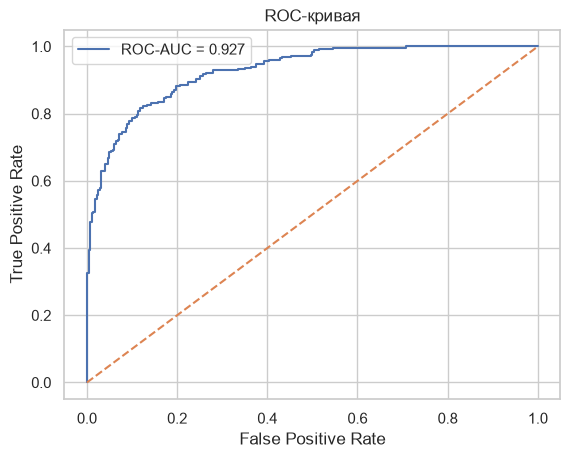

In [32]:
p = 0.55 * p_gb + 0.45 * p_extra
probabilities = BestGradientBoost.predict_proba(X_validation)[:,1]
fpr, tpr, thresholds = roc_curve(y_validation, p)
auc = roc_auc_score(y_validation, p)
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривая")
plt.legend()
plt.show()

In [33]:
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier

gb_final = GradientBoostingClassifier(
    learning_rate=0.15,
    max_depth=5,
    n_estimators=600,
    random_state=42
)

gb_final.fit(X_train, y_train)

p_gb_test = gb_final.predict_proba(X_test)[:, 1]


extra_final = ExtraTreesClassifier(
    n_estimators=1000,
    max_features=0.2,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

extra_final.fit(X_train, y_train)

p_extra_test = extra_final.predict_proba(X_test)[:, 1]


test_proba = (
    0.55 * p_gb_test +
    0.45 * p_extra_test
)


# 4. Submission
submission = pd.DataFrame({
    'row_id': test['row_id'],
    'target': test_proba
})

submission.to_csv('submission_alpha.csv', index=False)